# MIR: regridding Xarray data

In [1]:
import earthkit.data as ekd
import earthkit.plots as ekp

import earthkit.geo as ekg

Please note the Xarray support in regridding is experimental. The grid spec of the input data can only inferred in some special cases, otherwise it has to be specified manually.

## Xarray generated from GRIB with earthkit-data

In the first example we fetch GRIB data on 0.25°x0.25°  grid on a subarea and convert to Xarray with earthkit-data.

In [2]:
ds = ekd.from_source("sample", "era5_tquv_pl_subarea.grib").to_xarray()
ds

era5_tquv_pl_subarea.grib:   0%|          | 0.00/16.6M [00:00<?, ?B/s]

<xarray.Dataset> Size: 69MB
Dimensions:                  (forecast_reference_time: 4, level: 3,
                              latitude: 301, longitude: 601)
Coordinates:
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 32B 201...
  * level                    (level) int64 24B 700 850 925
  * latitude                 (latitude) float64 2kB 90.0 89.75 ... 15.25 15.0
  * longitude                (longitude) float64 5kB -100.0 -99.75 ... 50.0
Data variables:
    q                        (forecast_reference_time, level, latitude, longitude) float64 17MB ...
    t                        (forecast_reference_time, level, latitude, longitude) float64 17MB ...
    u                        (forecast_reference_time, level, latitude, longitude) float64 17MB ...
    v                        (forecast_reference_time, level, latitude, longitude) float64 17MB ...
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

The data generated in this way has the grid spec that can be accessed via the earthkit accessor.

In [3]:
ds.earthkit.grid_spec

{'area': [90, -100, 15, 50], 'grid': [0.25, 0.25]}

Now, we interpolate the data to a 5°x5°  regular latitude-longitude grid. Since the grid spec can be inferred from the dataset we only need to specify the ``out_grid``.

In [4]:
# the target grid is 5x5 degree regular latitude-longitude grid
out_grid = {"grid": [5, 5]}

# perform interpolation
ds_r = ekg.regrid(ds, out_grid=out_grid, interpolation="linear")
ds_r

<xarray.Dataset> Size: 191kB
Dimensions:                  (forecast_reference_time: 4, level: 3,
                              latitude: 16, longitude: 31)
Coordinates:
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 32B 201...
  * level                    (level) int64 24B 700 850 925
  * latitude                 (latitude) float64 128B 90.0 85.0 ... 20.0 15.0
  * longitude                (longitude) float64 248B -100.0 -95.0 ... 45.0 50.0
Data variables:
    q                        (forecast_reference_time, level, latitude, longitude) float64 48kB ...
    t                        (forecast_reference_time, level, latitude, longitude) float64 48kB ...
    u                        (forecast_reference_time, level, latitude, longitude) float64 48kB ...
    v                        (forecast_reference_time, level, latitude, longitude) float64 48kB ...

The resulting dataset still has the earthkit accessor with the correct grid spec set on it.

In [5]:
ds_r.earthkit.grid_spec

{'area': [90, -100, 15, 50], 'grid': [5, 5]}

We check the result visually by plotting the same data from the input and output dataset.

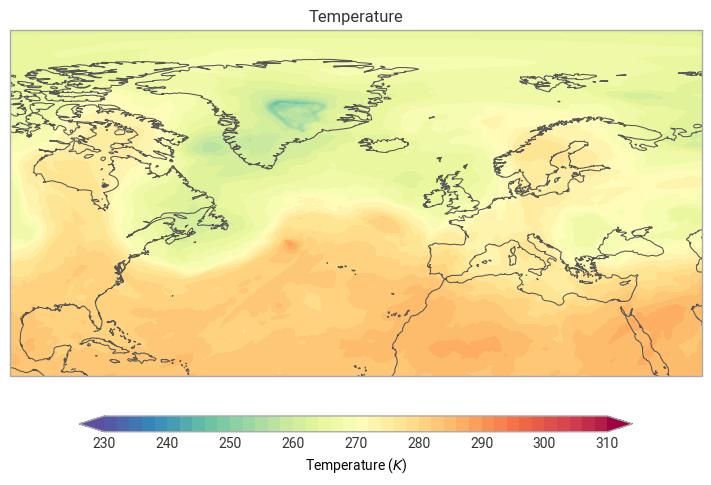

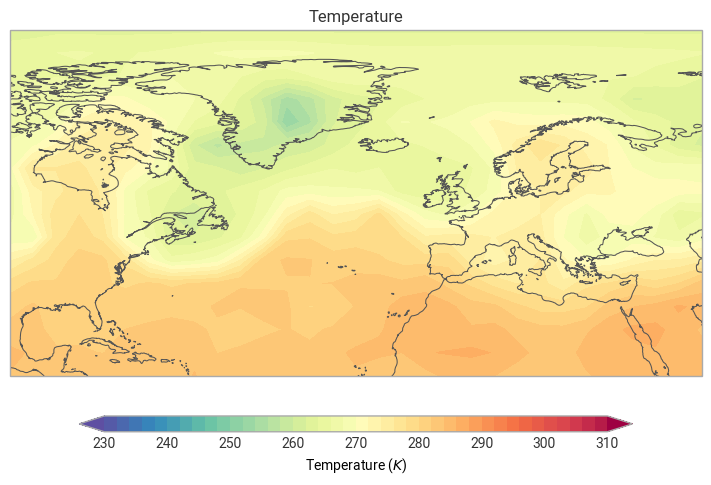

In [6]:
ekp.quickplot(ds.t.isel(forecast_reference_time=0, level=0))
ekp.quickplot(ds_r.t.isel(forecast_reference_time=0, level=0))

## Xarray generated from NetCDF

In this example the data is available on the same grid as in the previous example but the format is NetCDF. We fetch the file and load it into Xarray.

In [7]:
ds = ekd.from_source("sample", "era5_tquv_pl_subarea.nc").to_xarray()
ds

era5_tquv_pl_subarea.nc:   0%|          | 0.00/14.6M [00:00<?, ?B/s]

<xarray.Dataset> Size: 35MB
Dimensions:         (valid_time: 4, pressure_level: 3, latitude: 301,
                     longitude: 601)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 32B 2016-09-26 ... 2016-09-26...
  * pressure_level  (pressure_level) float64 24B 925.0 850.0 700.0
  * latitude        (latitude) float64 2kB 90.0 89.75 89.5 ... 15.5 15.25 15.0
  * longitude       (longitude) float64 5kB -100.0 -99.75 -99.5 ... 49.75 50.0
Data variables:
    q               (valid_time, pressure_level, latitude, longitude) float32 9MB ...
    t               (valid_time, pressure_level, latitude, longitude) float32 9MB ...
    u               (valid_time, pressure_level, latitude, longitude) float32 9MB ...
    v               (valid_time, pressure_level, latitude, longitude) float32 9MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-12T10:30 GRIB to CDM+CF via cfgrib-0.9.1...

Although the dataset has the earthkit accessor (it is always available when earthkit-data is installed) the grid spec is not available on it.

In [8]:
ds.earthkit.grid_spec  # returns None

In [9]:
in_grid = {"grid": [0.25, 0.25], "area": [90.0, -100.0, 15.0, 50.0]}

# the target grid is 5x5 degree regular latitude-longitude grid
out_grid = {"grid": [5, 5]}

ds_r = ekg.regrid(ds, in_grid=in_grid, out_grid=out_grid, interpolation="linear")
ds_r

<xarray.Dataset> Size: 96kB
Dimensions:         (valid_time: 4, pressure_level: 3, latitude: 16,
                     longitude: 31)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 32B 2016-09-26 ... 2016-09-26...
  * pressure_level  (pressure_level) float64 24B 925.0 850.0 700.0
  * latitude        (latitude) float64 128B 90.0 85.0 80.0 ... 25.0 20.0 15.0
  * longitude       (longitude) float64 248B -100.0 -95.0 -90.0 ... 45.0 50.0
Data variables:
    q               (valid_time, pressure_level, latitude, longitude) float32 24kB ...
    t               (valid_time, pressure_level, latitude, longitude) float32 24kB ...
    u               (valid_time, pressure_level, latitude, longitude) float32 24kB ...
    v               (valid_time, pressure_level, latitude, longitude) float32 24kB ...

We check the result visually by plotting the same data from the input and output dataset.

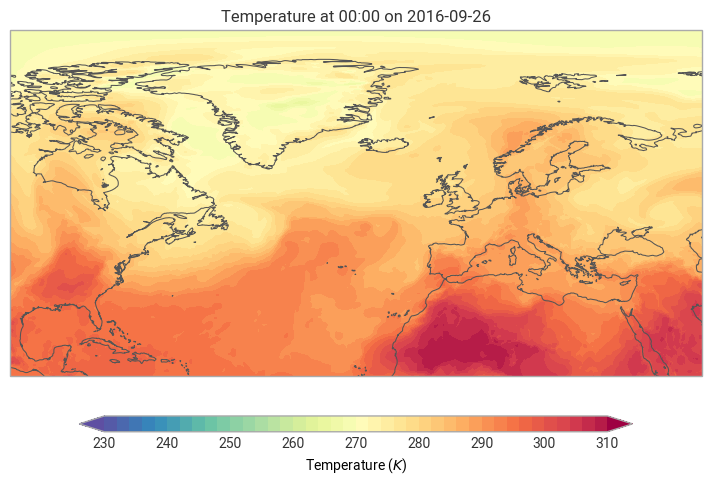

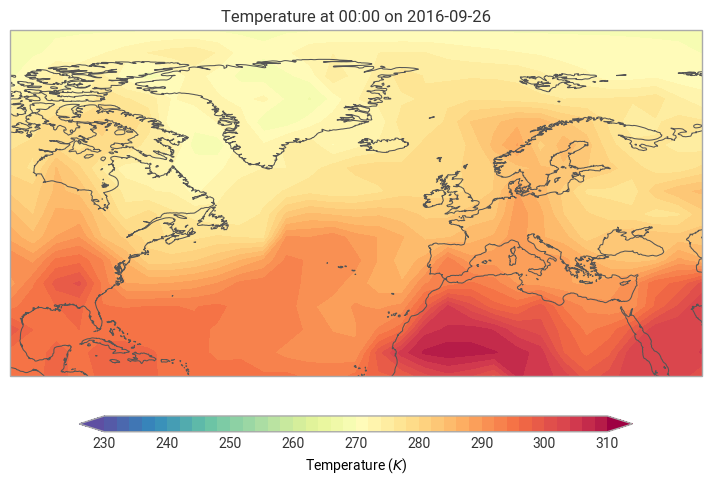

In [10]:
ekp.quickplot(ds.t.isel(valid_time=0, pressure_level=0))
ekp.quickplot(ds_r.t.isel(valid_time=0, pressure_level=0))